# Session 6 — Teacher demonstration: dynamic competitor prices

**Analyst investigation.** Once a week, a pricing analyst records standard subscription prices by city. This notebook demonstrates one historical snapshot. Run cells from top to bottom; the slides provide the business introduction.

Before class: install `requests`, `pandas`, `ipykernel`, `playwright`, and Playwright Chromium in the notebook's Python environment. Jupyter cells use Playwright's **async** API and top-level `await`. No student installation occurs during the exercise.


## 1. Start the local teaching page

The next cell starts a local Python server automatically. The browser and `requests` will use the same URL.


In [1]:
from pathlib import Path
from functools import partial
from http.server import SimpleHTTPRequestHandler, ThreadingHTTPServer
from threading import Thread
import sys

def find_sources():
    # Jupyter may start in the package root or inside the notebooks folder.
    for parent in (Path.cwd(), *Path.cwd().parents):
        for candidate in (parent, parent / "S6_sources"):
            if (candidate / "data" / "student" / "index.html").is_file():
                return candidate.resolve()
    raise FileNotFoundError("Open the extracted S6 package folder in VS Code, then run this cell again.")

SOURCE_ROOT = find_sources()

class QuietHandler(SimpleHTTPRequestHandler):
    def log_message(self, *args):
        pass  # Keep repeated browser requests out of the projected notebook.

if "s6_server" not in globals():
    # Port 0 lets the OS choose an available port on this computer.
    handler = partial(QuietHandler, directory=str(SOURCE_ROOT))
    s6_server = ThreadingHTTPServer(("127.0.0.1", 0), handler)
    Thread(target=s6_server.serve_forever, daemon=True).start()

BASE_URL = f"http://127.0.0.1:{s6_server.server_port}"
print("Local page:", BASE_URL)
print("Notebook Python:", sys.executable)

DEMO_URL = BASE_URL + "/data/demo/"
print("Demonstration:", DEMO_URL)


Local page: http://127.0.0.1:61103
Notebook Python: /Users/guillaumeleorat/Projects/Teaching/AlbertSchool/Advanced_EDA_DataCollection/.venv/bin/python
Demonstration: http://127.0.0.1:61103/data/demo/


## 2. Compare the browser view and the first HTTP response

Open the displayed URL. The standard offers become visible in the browser. Now ask whether the initial HTML includes a distinctive standard price, **€44.90**.


In [2]:
import requests

response = requests.get(DEMO_URL, timeout=10)
response.raise_for_status()
raw_html = response.text
print("HTTP status:", response.status_code)
print("Standard price in initial HTML:", "44.90" in raw_html)
print("Offer cards mentioned in initial HTML:", "offer-card" in raw_html)
print("A script is referenced:", "app.js" in raw_html)
assert "44.90" not in raw_html  # The separate promotional card does exist in the initial HTML.


HTTP status: 200
Standard price in initial HTML: False
Offer cards mentioned in initial HTML: True
A script is referenced: True


**Pause:** the HTTP request worked. The browser later changed the document. Could an official download, documented API or suitable structured response answer the same question? The synthetic teaching page has none for the six standard offers; parsing undocumented application JavaScript would itself be fragile. Browser rendering is justified for this worked example.


## 3. Open the page with a real browser

Playwright runs the page's JavaScript. Wait for the page's *ready state*, not a fixed number of seconds.


Standard price in rendered HTML: True
<!DOCTYPE html><html lang="en"><head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>MarketLens | Weekly competitor price watch</title>
  <link rel="stylesheet" href="../shared/style.css">
  <script defer="" src="app.js"></script>
</head>
<body>
  <main class="shell">
    <p class="eyebrow">Controlled teaching source · MarketLens</p>
    <h1>Competitor subscription prices</h1>
    <p>Reference: 16 September 2026, 09:00 CEST. Monthly EUR prices, standard offers, taxes included. Illustrative synthetic data.</p>
    <aside class="notice" aria-label="Source information">Source: MarketLens teaching dashboard. No official download or documented API is offered for this exact snapshot.</aside>
    <aside class="promotions" aria-label="Introductory promotion">
      <h2>Promotion — separate from standard offers</h2>
      <div class="offer-card"><strong>Intro month</strong><span>€9.90 for the first m

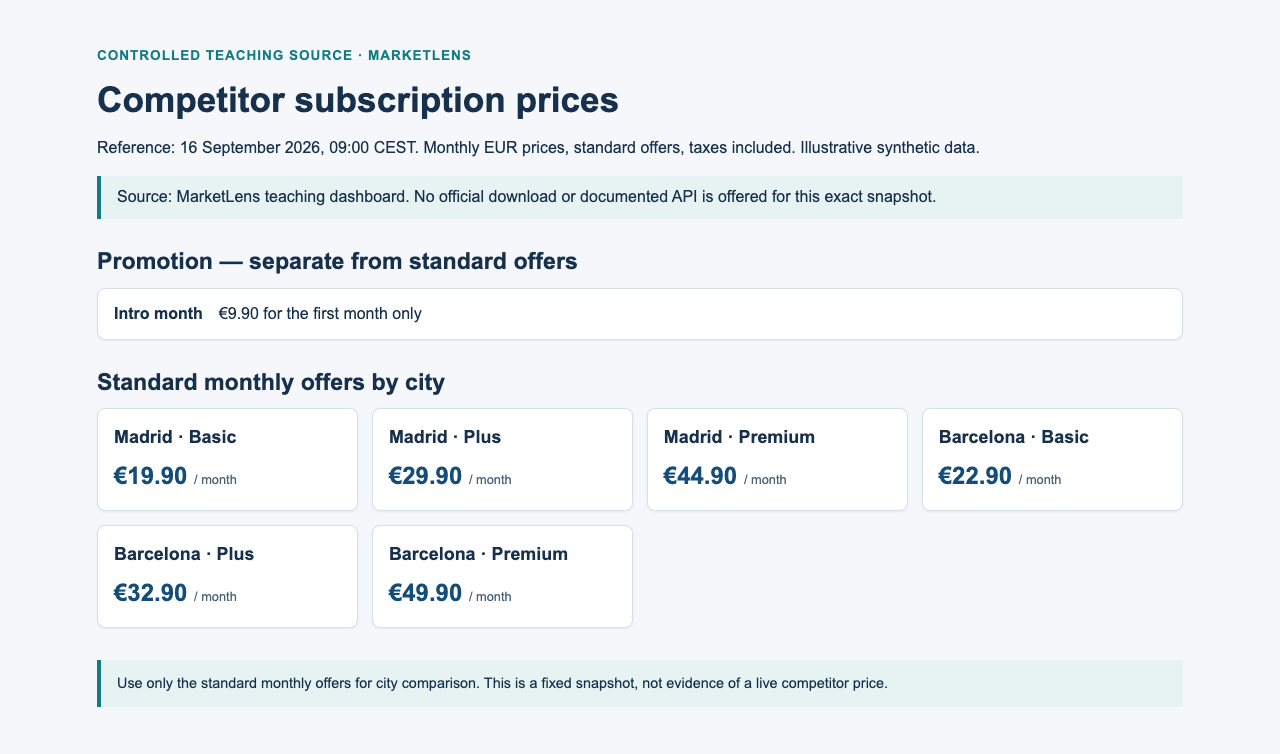

In [3]:
from playwright.async_api import async_playwright
from IPython.display import display, Image

playwright = await async_playwright().start()
browser = await playwright.chromium.launch(headless=True)
page = await browser.new_page()
await page.goto(DEMO_URL)
await page.locator('#standard-prices[data-ready="true"]').wait_for(timeout=10000)
# Inspect the HTML after JavaScript has filled the price cards.
rendered_html = await page.content()
print("Standard price in rendered HTML:", "44.90" in rendered_html)
print(rendered_html[:2000])
display(Image(data=await page.screenshot(full_page=True)))


## 4. Inspect the rendered target before extracting

The introductory promotion has the same card class. Compare a broad locator with a locator limited to **standard prices**.


In [4]:
all_cards = page.locator(".offer-card")
standard_cards = page.locator("#standard-prices .offer-card")
print("All offer cards:", await all_cards.count())
print("Standard cards:", await standard_cards.count())
print("First standard card:", await standard_cards.first.inner_text())
# Show why the broader selector is not the business target.
print("Promotion:", await page.locator(".promotions .offer-card").first.inner_text())


All offer cards: 7
Standard cards: 6
First standard card: Madrid · Basic

€19.90 / month
Promotion: Intro month
€9.90 for the first month only


## 5. Build the analytical table

**Grain:** one city and one plan at the reference time. Keep the reference time and collection time distinct.


In [5]:
import re
import pandas as pd

collected_at = pd.Timestamp.now(tz="Europe/Madrid")
reference_at = pd.Timestamp("2026-09-16T09:00:00+02:00")
rows = []
for i in range(await standard_cards.count()):
    card = standard_cards.nth(i)
    price_text = await card.locator(".price").inner_text()
    # The number is inside display text such as '€19.90 / month'.
    monthly_eur = float(re.search(r"\d+\.\d{2}", price_text).group())
    rows.append({
        "city": await card.get_attribute("data-city"),
        "plan": await card.get_attribute("data-plan"),
        "monthly_eur": monthly_eur,
        "reference_at": reference_at,
        "collected_at": collected_at,
        "source_url": DEMO_URL,
    })
offers_df = pd.DataFrame(rows)
display(offers_df)


,city,plan,monthly_eur,reference_at,collected_at,source_url
0,Madrid,Basic,19.9,2026-09-16 09:00:00+02:00,2026-09-27 13:14:42.923996+02:00,http://127.0.0.1:61103/data/demo/
1,Madrid,Plus,29.9,2026-09-16 09:00:00+02:00,2026-09-27 13:14:42.923996+02:00,http://127.0.0.1:61103/data/demo/
2,Madrid,Premium,44.9,2026-09-16 09:00:00+02:00,2026-09-27 13:14:42.923996+02:00,http://127.0.0.1:61103/data/demo/
3,Barcelona,Basic,22.9,2026-09-16 09:00:00+02:00,2026-09-27 13:14:42.923996+02:00,http://127.0.0.1:61103/data/demo/
4,Barcelona,Plus,32.9,2026-09-16 09:00:00+02:00,2026-09-27 13:14:42.923996+02:00,http://127.0.0.1:61103/data/demo/
5,Barcelona,Premium,49.9,2026-09-16 09:00:00+02:00,2026-09-27 13:14:42.923996+02:00,http://127.0.0.1:61103/data/demo/


## 6. Validate the extraction against the displayed source

The numbers below are known reference results for this **fixed teaching snapshot**. Check structure, key, scope and two visible values.


In [6]:
assert len(offers_df) == 6
assert offers_df[["city", "plan"]].duplicated().sum() == 0
assert offers_df.groupby("city").size().to_dict() == {"Barcelona": 3, "Madrid": 3}
assert set(offers_df["plan"]) == {"Basic", "Plus", "Premium"}
assert 9.90 not in offers_df["monthly_eur"].tolist()  # Intro offer is outside the scope.
prices = offers_df.set_index(["city", "plan"])["monthly_eur"]
assert prices.loc[("Madrid", "Premium")] == 44.90
assert prices.loc[("Barcelona", "Premium")] == 49.90
print("Validated: 6 standard offers; 2 cities × 3 plans; no duplicated key.")


Validated: 6 standard offers; 2 cities × 3 plans; no duplicated key.


## 7. Give a bounded answer and close the browser


In [7]:
premium_gap = prices.loc[("Barcelona", "Premium")] - prices.loc[("Madrid", "Premium")]
print(f"At the reference time, Barcelona Premium exceeds Madrid Premium by €{premium_gap:.2f} per month.")
print("One synthetic snapshot cannot establish a price trend or justify a pricing change.")
await browser.close()
await playwright.stop()


At the reference time, Barcelona Premium exceeds Madrid Premium by €5.00 per month.
One synthetic snapshot cannot establish a price trend or justify a pricing change.


**Debrief:** A running browser proves access to a rendered page. The targeted, checked table supports only a narrow comparison. Before repeated use on a real website, document owner, access and reuse conditions, refresh cadence, selectors and failures. Move to the different student case.
